# Factor: volatility_of_volatility_convexity — AI-GENERATED (agent pipeline)

**AI-track annotation (required):** the factor logic between the
`BEGIN/END AI-GENERATED FACTOR LOGIC` markers was composed by an LLM agent
(Google Gemini, model logged per-generation) inside our evolutionary mining
loop and is included VERBATIM. Provenance: run `run_20260725_000122Z`, generation 4;
full audit trail (`prompts_gen_04.md`, `response_gen_04.md`) ships with this
submission and in the team AI Application Document. Human-written parts: the
data plumbing (SQL daily-bar derivation, gates), clearly separated.

**Rationale (agent's own):** "Orderly volume accumulation characterized by compressed range volatility-of-volatility relative to return volatility."

**Measured offline (fair-pool comparison vs our live 0.65-scoring factor):**
IC +0.0265 · ICIR 0.40 · net LS Sharpe 2.38 (best Part-A profile mined) · stress-ICIR 0.19 · ModelScore 0.511 / selected 37% (parity with the 0.65-scorer's 0.516/39%) · corr to vwsc +0.45 — RESERVE: submit after 04's public score reads. Passed the perturbation causality gate. SIGN = +1.0 (baked in).

**Contract (aligned to the official factor_hf template, and to the REAL
platform schema verified in AI Studio 2026-07-25):** `main(datasources,
start_date, end_date)`, datasources dict; daily key `date::DATE`;
volume/amount are PER-MINUTE (SUM = day total, CAST AS DOUBLE); output
`date, instrument, factor`, no inf; eval via `M.bigalpha_eval._latest`.

In [1]:
import numpy as np
import pandas as pd

SIGN = +1.0            # from research orientation (archive.csv)
WARMUP_CAL_DAYS = 90   # >= ~60 trading days for the nested rolling windows

# REAL schema: day key = date::DATE; prices ADJUSTED via adjust_factor (cross-
# day returns need split/dividend correction; same-day ratios are invariant);
# volume/amount are PER-MINUTE -> SUM = day total; CAST AS DOUBLE (DuckDB
# SUM(BIGINT) -> Decimal poisons pandas arithmetic).
DAILY_BARS_SQL = """
SELECT date::DATE::DATETIME AS date, instrument,
       MAX(high) * LAST(adjust_factor ORDER BY date) AS high,
       MIN(low)  * LAST(adjust_factor ORDER BY date) AS low,
       LAST(close ORDER BY date) * LAST(adjust_factor ORDER BY date) AS close,
       CAST(SUM(volume) AS DOUBLE) AS volume,
       CAST(SUM(amount) AS DOUBLE) AS dollar
FROM {table}
GROUP BY date::DATE, instrument
ORDER BY date, instrument
"""

# ================== BEGIN AI-GENERATED FACTOR LOGIC ==================
# VERBATIM from agent run run_20260725_000122Z / factors/
# volatility_of_volatility_convexity.py — do not edit (audit-reproducible)
def factor(close, high, low, volume, dollar):
    range_ratio = (high - low) / close.replace(0, np.nan)
    range_vol = range_ratio.rolling(5, min_periods=3).std()
    range_vol_vol = range_vol.rolling(20, min_periods=10).std()
    ret_vol = close.pct_change().rolling(20, min_periods=10).std()
    vol_momo = volume / volume.rolling(20, min_periods=10).mean().replace(0, np.nan)
    vol_momo_smooth = vol_momo.rolling(5, min_periods=3).mean()
    vol_of_vol_ratio = range_vol_vol / ret_vol.replace(0, np.nan)
    res = -1.0 * vol_of_vol_ratio * vol_momo_smooth
    return res.shift(1)
# =================== END AI-GENERATED FACTOR LOGIC ===================


def main(datasources, start_date, end_date):
    """Evaluator substitutes datasources/start_date/end_date and calls this.
    datasources (dict): {logical name: physical table}; we use "bar1m".
    Returns pd.DataFrame['date','instrument','factor'], no inf."""
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    q_start = (start - pd.Timedelta(days=WARMUP_CAL_DAYS)).strftime("%Y-%m-%d 00:00:00")
    q_end = end.strftime("%Y-%m-%d 23:59:59")

    bars = dai.query(DAILY_BARS_SQL.format(table=bar1m),
                     filters={"date": [q_start, q_end]}, compression=True).df()
    bars["date"] = pd.to_datetime(bars["date"])
    bars["instrument"] = bars["instrument"].astype(str)

    wide = {c: bars.pivot(index="date", columns="instrument", values=c).sort_index().astype("float64")
            for c in ("close", "high", "low", "volume", "dollar")}
    fac = factor(wide["close"], wide["high"], wide["low"],
                 wide["volume"], wide["dollar"])
    fac = fac.where(np.isfinite(fac))                # contract: no inf

    out = fac.stack().rename("factor").reset_index()
    out["factor"] = SIGN * out["factor"]

    cons = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                     filters={"date": [start_date, end_date]}).df()
    cons["date"] = pd.to_datetime(cons["date"])
    cons["instrument"] = cons["instrument"].astype(str)
    out = cons.merge(out, on=["date", "instrument"], how="left")
    out = out.loc[(out["date"] >= start) & (out["date"] <= end)].copy()
    out["factor"] = out["factor"].fillna(0.0)   # no computable value = neutral

    exp_days = cons.loc[(cons["date"] >= start) & (cons["date"] <= end),
                        "date"].drop_duplicates()
    missing = exp_days[~exp_days.isin(out["date"].unique())]
    if len(missing) > 0:
        raise ValueError(f"GATE FAIL: {len(missing)} trading days missing")
    cov = out.groupby("date")["factor"].apply(lambda s: s.notna().mean()).min()
    if not (cov >= 0.60):
        raise ValueError(f"GATE FAIL: worst per-day coverage {cov:.1%} < 60%")
    return out[["date", "instrument", "factor"]]

(242000, 3) 2024-01-02 00:00:00 2024-12-31 00:00:00
[2026-07-25 19:26:08] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-25 19:26:10] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-25 19:26:15] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-25 19:26:19] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-25 19:26:19] [info     ] ========== 数据检查 ==========
[2026-07-25 19:26:19] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflo

时段,IC
2024-01-15~2024-02-08,-0.0027
2024-09-24~2024-10-08,0.0205

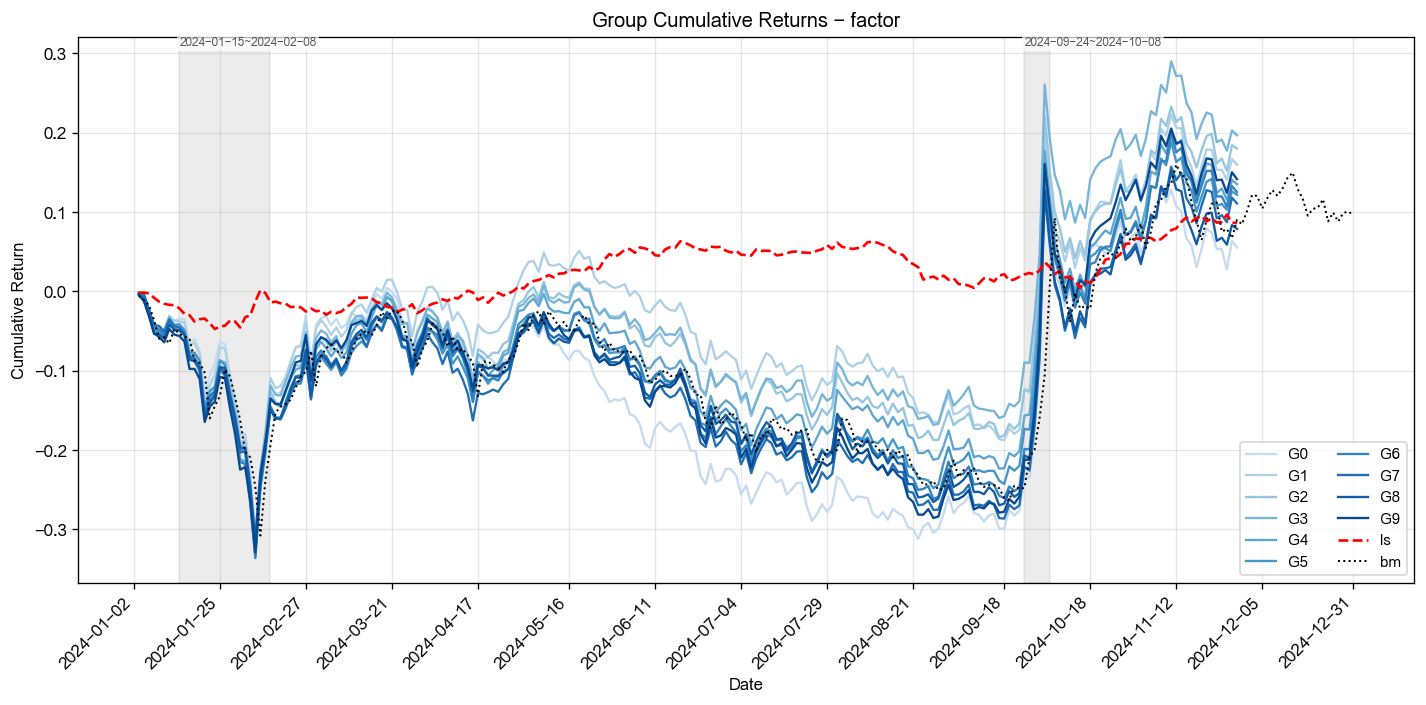
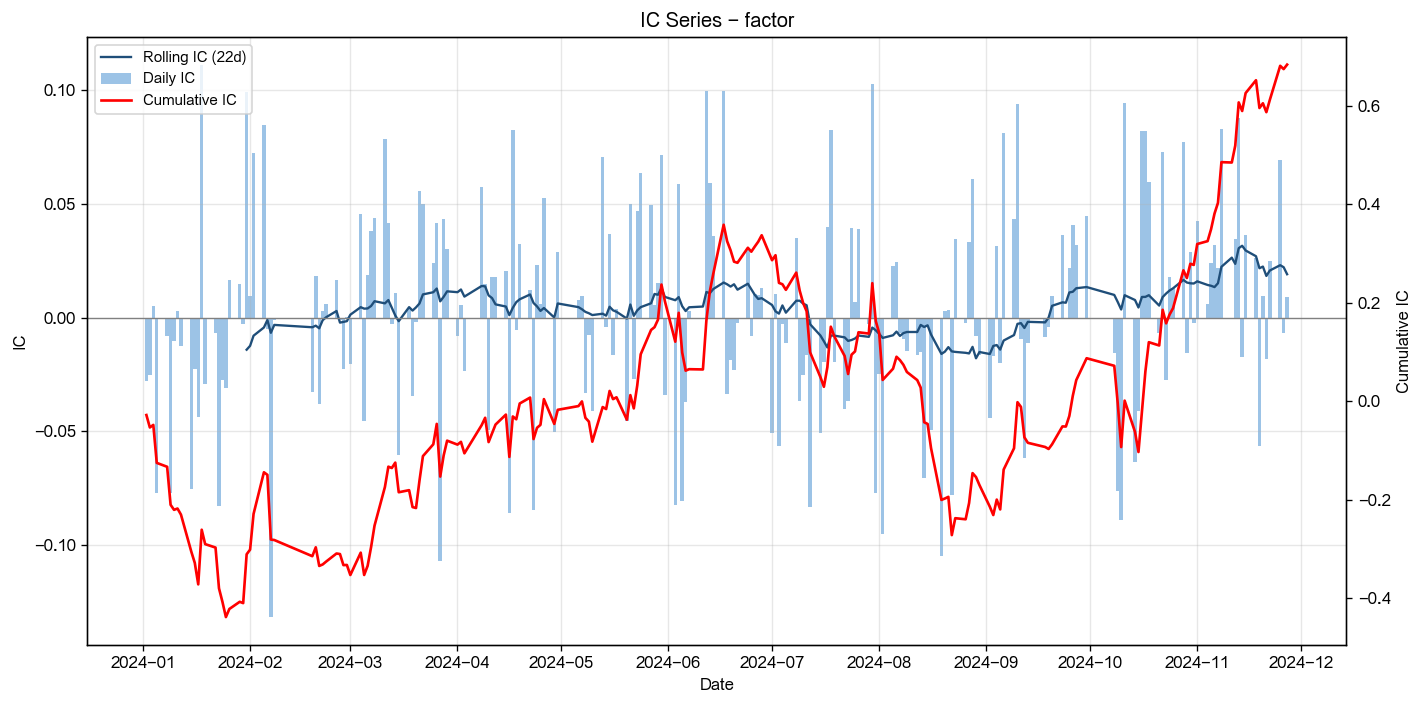
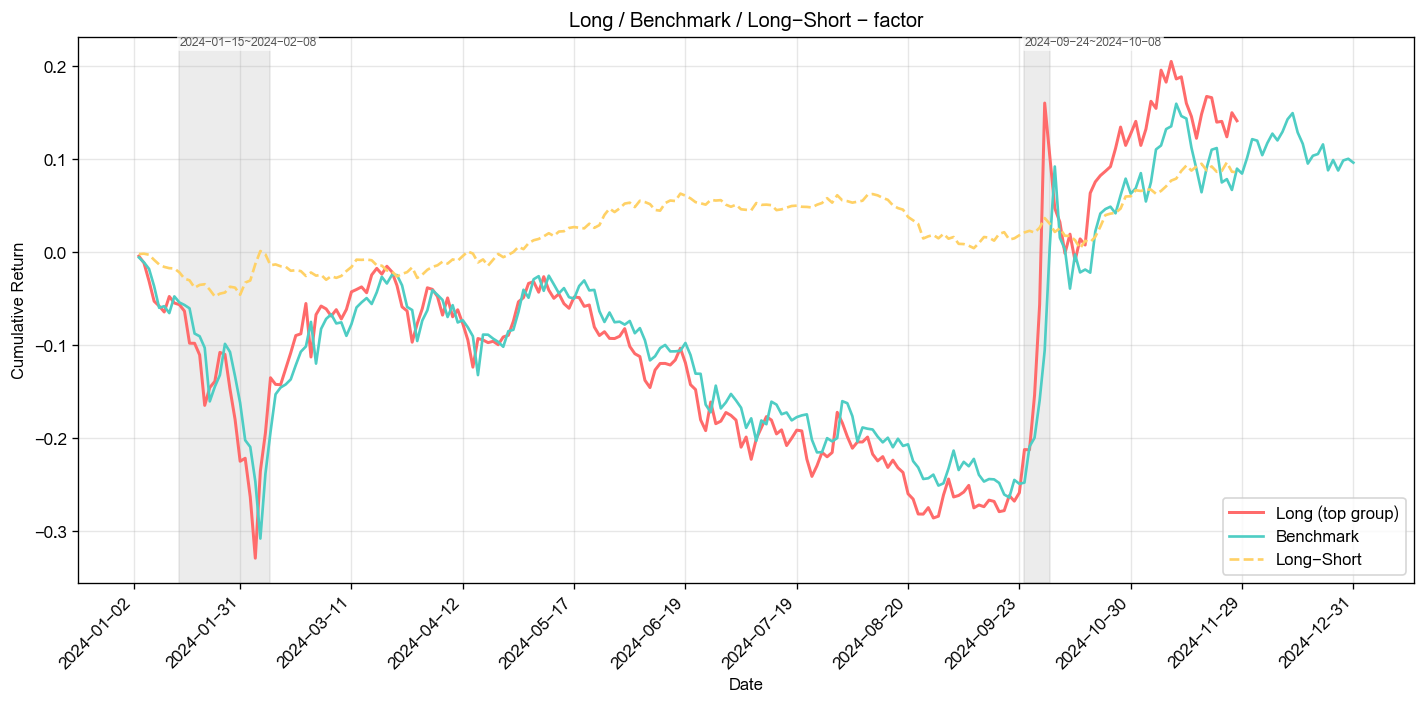
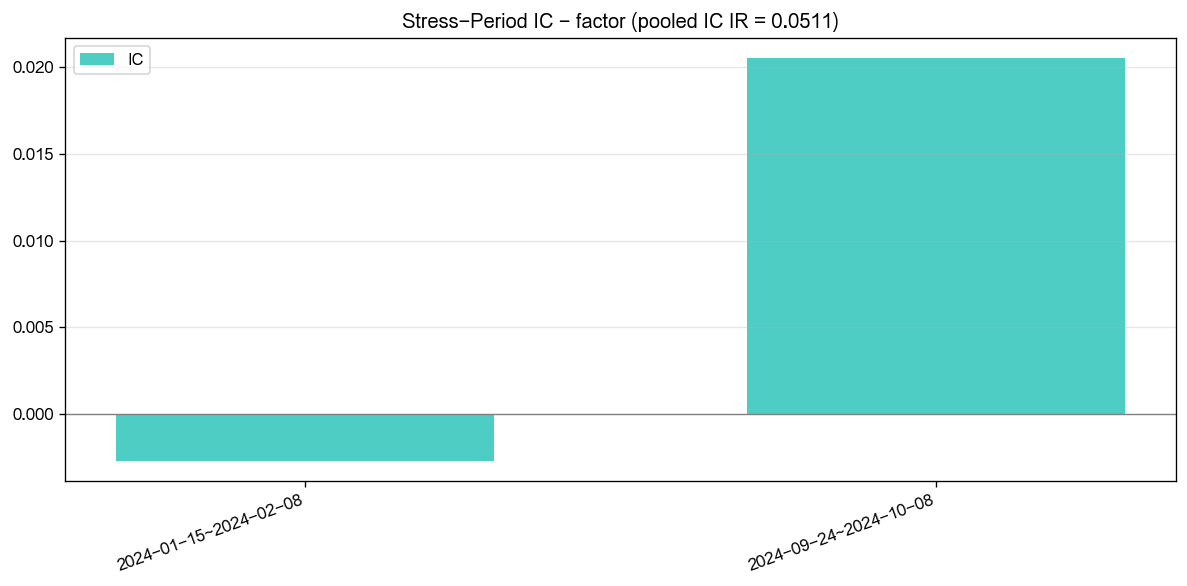
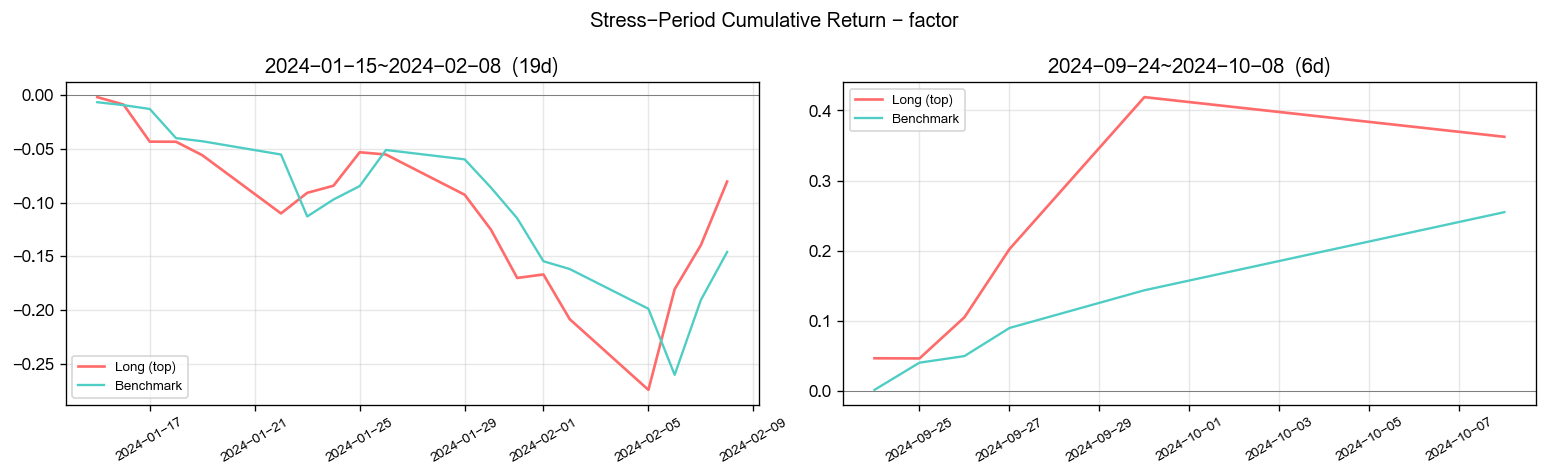

[2026-07-25 19:31:51] [info     ] ========== 因子池回归 ==========
[2026-07-25 19:31:52] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-25 19:31:55] [info     ] 获取收益率数据, 耗时: 3.5347 秒
[2026-07-25 19:31:57] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.7437 秒
[2026-07-25 19:31:57] [info     ] 统计 回归结果, 耗时: 0.0088 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9718,0.0447,0.0227,1.0000
2,amount,1.7274,0.0185,0.0107,0.9000
3,netflow_amount_rate_main,1.5504,0.0099,0.0064,1.0000
4,netflow_amount_main,1.5108,0.0252,0.0167,1.0000
5,gross_profit_rate_ttm,1.4989,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4519,0.0040,0.0028,0.8000
7,bias_20,1.4325,0.0290,0.0203,0.9000
8,pb,1.4299,0.0096,0.0067,1.0000
9,cci_14,1.3846,0.0338,0.0244,1.0000
10,pe_ttm,1.3224,0.0029,0.0022,0.9000

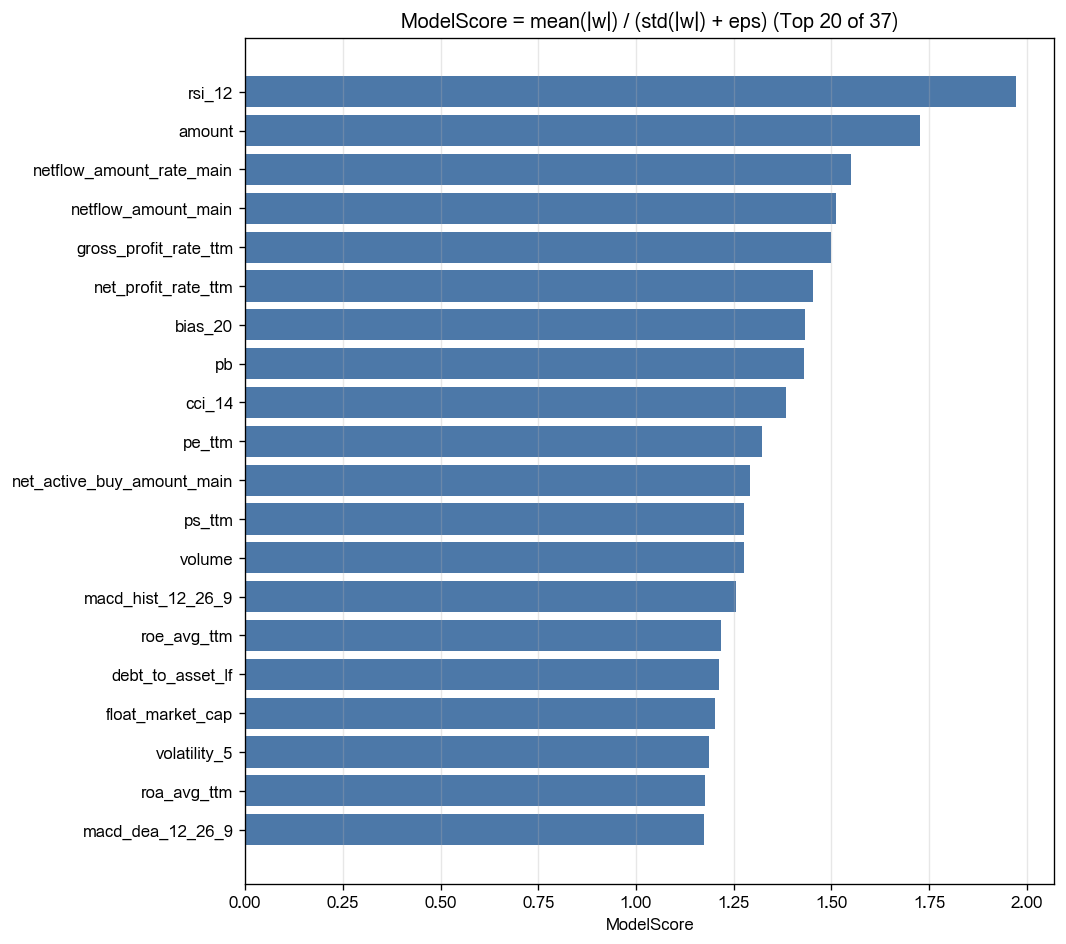
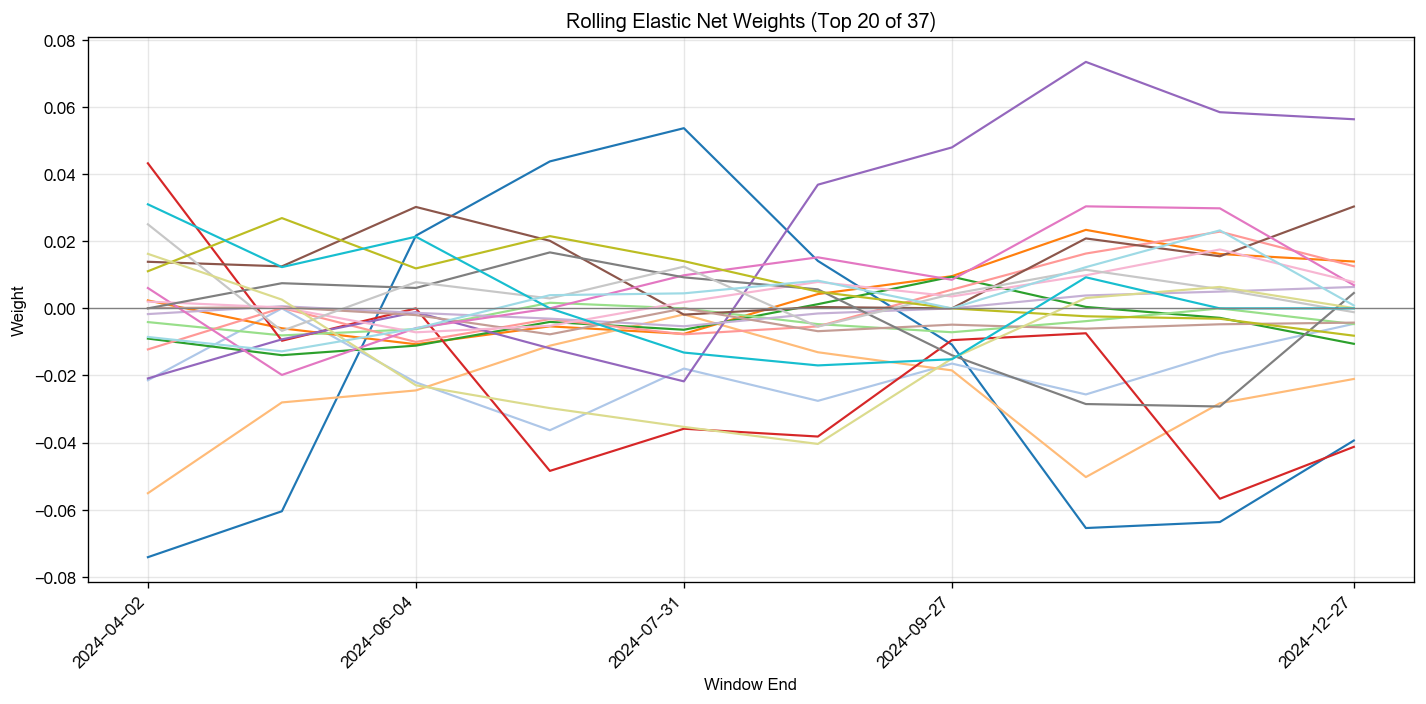
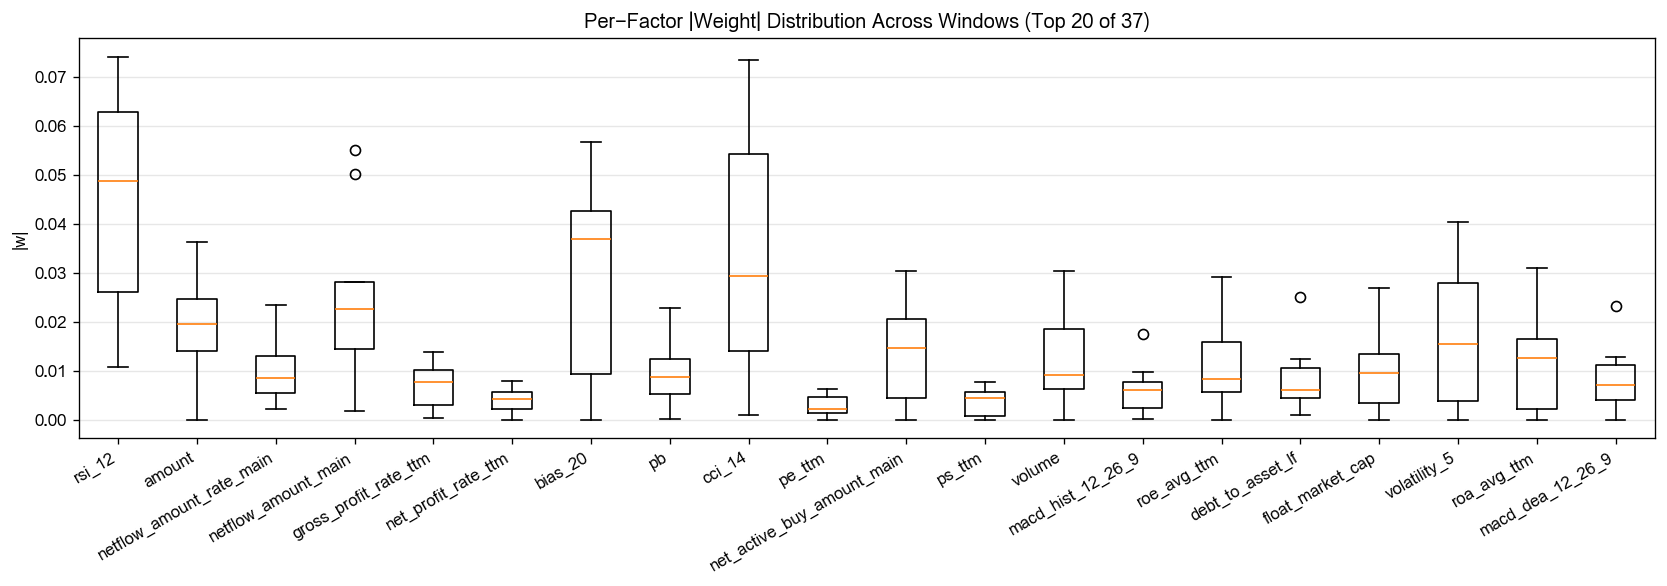
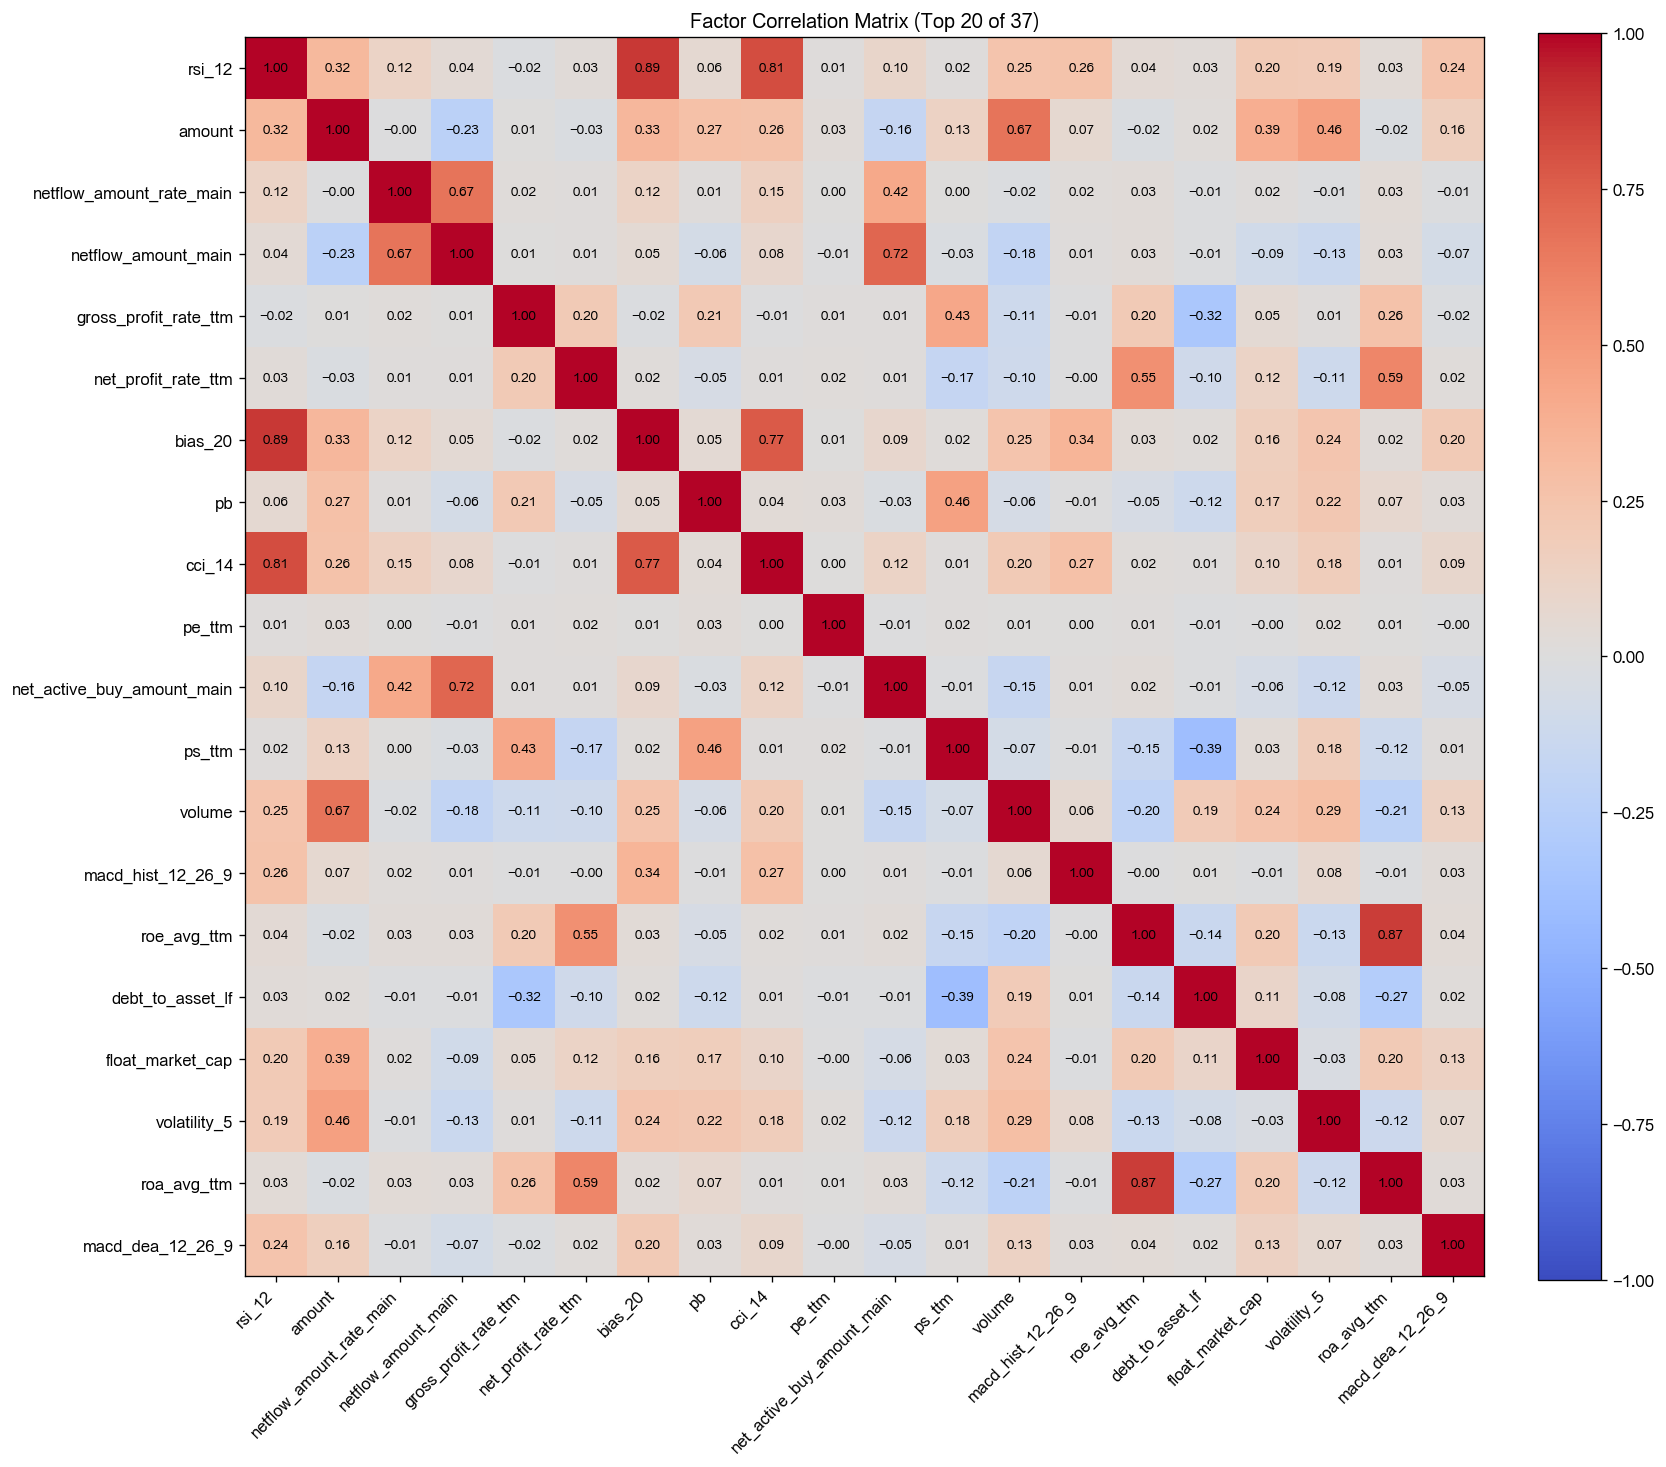

[2026-07-25 19:32:00] [warning  ] 返回的Outputs实例(size=35445543) 大于 64K, 将不会被缓存
[2026-07-25 19:32:00] [info     ] bigalpha_eval.v4 运行完成 [349.370s].


In [2]:
# ===== evaluation (exact official factor_hf pattern) =====
if __name__ == '__main__':
    from bigmodule import M
    import dai

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    factor_data = main(datasources, start_date, end_date)
    print(factor_data.shape, factor_data['date'].min(), factor_data['date'].max())

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )